# Boosted Decision Tree Skeleton


In [1]:
import awkward as ak
import uproot
import polars as pl

from fastfeedback import DataManager, Method

method = 0b00
direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
energy_reco = Method.Truth if method & 1 << 1 else Method.Reco

print(f"""
Direction reconstruction: {direc_reco.name}
Energy reconstruction:    {energy_reco.name}
""")

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")
data_manager.set_direc_reco(direc_reco)
data_manager.set_energy_reco(energy_reco)

df = data_manager.prepare_data()
df = df["nuPDG", "recoE", "direc_reco"]

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"

data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range])
df2: pl.DataFrame = pl.from_pandas(ak.to_dataframe(data, how="outer"))
df2.columns = ["Enu_e_had", "Enu_e_calo", "Enu_mu_had", "Enu_mu_range"]

event_daughters_tree = uproot.open("example-cafs-root/event_daughters_info.root")[
    "event_daughters_tree"
]
event_daughters_df: pl.DataFrame = pl.from_pandas(
    event_daughters_tree.arrays(library="pd")
)

electron_mask = pl.col("nuPDG").abs() == 12
muon_mask = pl.col("nuPDG").abs() == 14

electron_inelasticity = 1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))
muon_inelasticity = 1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))

nu_mask = pl.col("nuPDG") > 0
nubar_mask = pl.col("nuPDG") < 0

data: pl.DataFrame = (
    pl.concat([df, df2, event_daughters_df], how="horizontal")
    .filter(pl.col("reco_ok") == True)
    .filter(pl.col("direc_reco") != 0)
    .with_columns(
        pl.when(electron_mask)
        .then(electron_inelasticity)
        .when(muon_mask)
        .then(muon_inelasticity)
        .otherwise(None)
        .alias("inelasticity")
    )
    .drop_nulls()
)

data


Direction reconstruction: Reco
Energy reconstruction:    Reco

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


nuPDG,recoE,direc_reco,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,n_true_nu,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_pi0s,n_primary_tracks,n_primary_showers,inelasticity
i32,f64,f64,f32,f32,f32,f32,bool,i32,i32,i32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32
-12,28.432413,-0.291152,12.376396,28.432413,28.015844,28.529816,true,10,5,4,11.48799,4,1,1,5,1,0,0,1,0,1,1,3,0.564708
-12,0.208079,0.092648,0.09995,0.208079,0.09995,0.322256,true,2,1,0,0.11094,1,0,1,4,1,0,1,0,1,0,1,1,0.519653
-14,1.20171,0.167917,0.306345,1.156426,0.306345,1.20171,true,4,3,0,0.06457,2,1,1,6,0,1,0,2,0,0,3,0,0.745076
-12,0.309697,0.373755,0.0,0.021875,0.0,0.1223,true,2,1,0,0.003319,1,0,1,3,0,0,1,0,1,0,1,0,1.0
-14,1.18506,0.784457,0.05674,0.254377,0.05674,0.508249,true,2,1,0,0.010483,0,1,1,3,0,0,1,0,0,0,1,0,0.888362
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
14,3.704717,0.113819,0.212121,4.272606,4.230925,4.359765,true,7,4,1,0.274192,3,1,1,3,0,0,1,1,0,0,2,0,0.029552
14,2.243878,0.899609,0.15033,0.348143,0.15033,0.389632,true,2,0,1,0.037859,0,0,1,38,1,0,19,0,1,0,19,1,0.614174
14,0.260973,-0.396677,0.0,0.012357,0.0,0.011892,true,3,1,1,0.018882,0,1,1,2,1,0,1,0,0,0,1,1,1.0


In [2]:
# import matplotlib.pyplot as plt

# for col in data.columns:
#     if col in ["run", "nuPDG", "isCC", "mode", "reco_pdg"]:
#         continue

#     _, bins, _ = plt.hist(
#         data.filter(nu_mask)[col],
#         label="neutrino",
#         histtype="step",
#         bins=20,
#         density=True,
#     )
#     plt.hist(
#         data.filter(nubar_mask)[col],
#         label="antineutrino",
#         histtype="step",
#         bins=bins,
#         density=True,
#     )
#     plt.legend()
#     plt.yscale("log")
#     plt.xlabel(col)
#     plt.ylabel("Events")
#     plt.show()

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

# get your input data into an array which is N_events x N_variables
X_data = data.drop("nuPDG")

# create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
y_data = (data["nuPDG"] < 0).to_numpy().astype(int)
y_data_uniques = np.unique(y_data)
print(y_data_uniques)

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, random_state=0)
X_data

[0 1]


recoE,direc_reco,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,n_true_nu,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_pi0s,n_primary_tracks,n_primary_showers,inelasticity
f64,f64,f32,f32,f32,f32,bool,i32,i32,i32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32
28.432413,-0.291152,12.376396,28.432413,28.015844,28.529816,true,10,5,4,11.48799,4,1,1,5,1,0,0,1,0,1,1,3,0.564708
0.208079,0.092648,0.09995,0.208079,0.09995,0.322256,true,2,1,0,0.11094,1,0,1,4,1,0,1,0,1,0,1,1,0.519653
1.20171,0.167917,0.306345,1.156426,0.306345,1.20171,true,4,3,0,0.06457,2,1,1,6,0,1,0,2,0,0,3,0,0.745076
0.309697,0.373755,0.0,0.021875,0.0,0.1223,true,2,1,0,0.003319,1,0,1,3,0,0,1,0,1,0,1,0,1.0
1.18506,0.784457,0.05674,0.254377,0.05674,0.508249,true,2,1,0,0.010483,0,1,1,3,0,0,1,0,0,0,1,0,0.888362
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.704717,0.113819,0.212121,4.272606,4.230925,4.359765,true,7,4,1,0.274192,3,1,1,3,0,0,1,1,0,0,2,0,0.029552
2.243878,0.899609,0.15033,0.348143,0.15033,0.389632,true,2,0,1,0.037859,0,0,1,38,1,0,19,0,1,0,19,1,0.614174
0.260973,-0.396677,0.0,0.012357,0.0,0.011892,true,3,1,1,0.018882,0,1,1,2,1,0,1,0,0,0,1,1,1.0


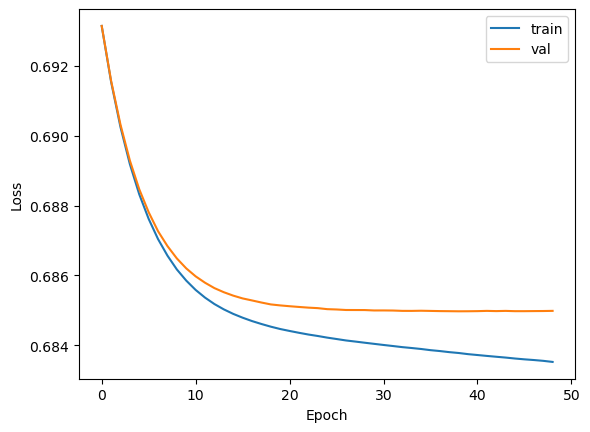

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt

clf = HistGradientBoostingClassifier(random_state=0, class_weight="balanced").fit(
    X_train, y_train
)

scores_train = clf.decision_function(X_train)
scores_test = clf.decision_function(X_test)

train_loss = -clf.train_score_
val_loss = -clf.validation_score_

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

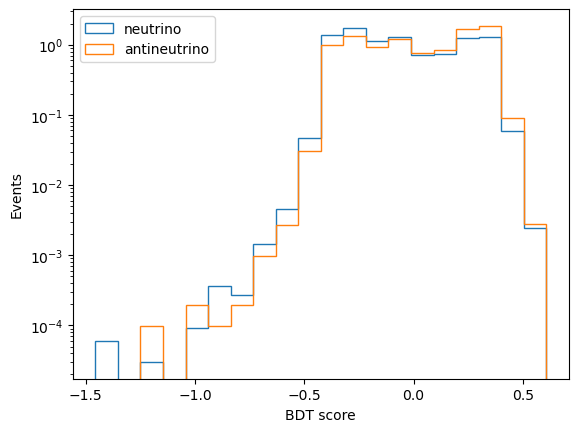

9.691074541511


In [5]:
nu_index = 0
nubar_index = 1

n, bins, _ = plt.hist(
    scores_test[y_test == nu_index],
    label="neutrino",
    histtype="step",
    bins=20,
    range=(scores_test.min(), scores_test.max()),
    density=True,
)
plt.hist(
    scores_test[y_test == nubar_index],
    label="antineutrino",
    histtype="step",
    bins=bins,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("BDT score")
plt.ylabel("Events")
plt.show()

print(np.sum(n))

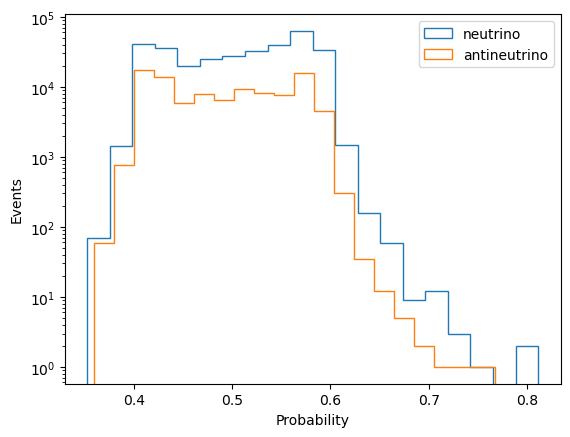

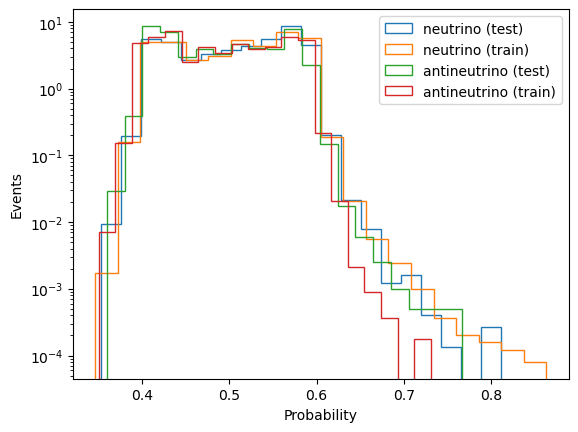

In [6]:
prob_test_nu = 1 / (1 + np.exp(scores_test[y_test == nu_index]))
prob_test_nubar = 1 / (1 + np.exp(scores_test[y_test == nubar_index]))
prob_train_nu = 1 / (1 + np.exp(scores_train[y_train == nu_index]))
prob_train_nubar = 1 / (1 + np.exp(scores_train[y_train == nubar_index]))

_, bins, _ = plt.hist(prob_test_nu, label="neutrino", histtype="step", bins=20)
plt.hist(prob_test_nubar, label="antineutrino", histtype="step", bins=20)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

_, bins, _ = plt.hist(
    prob_test_nu, label="neutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nu, label="neutrino (train)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_test_nubar, label="antineutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nubar,
    label="antineutrino (train)",
    histtype="step",
    bins=20,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

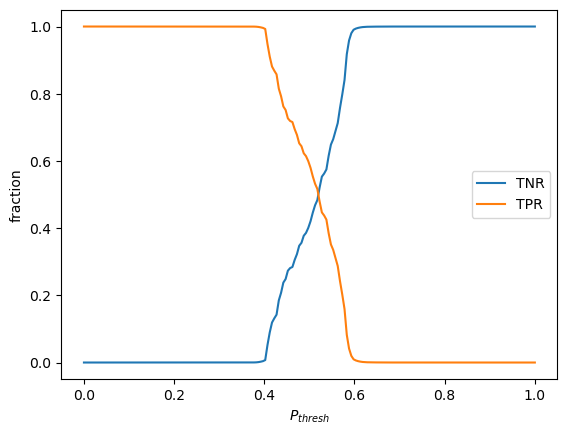

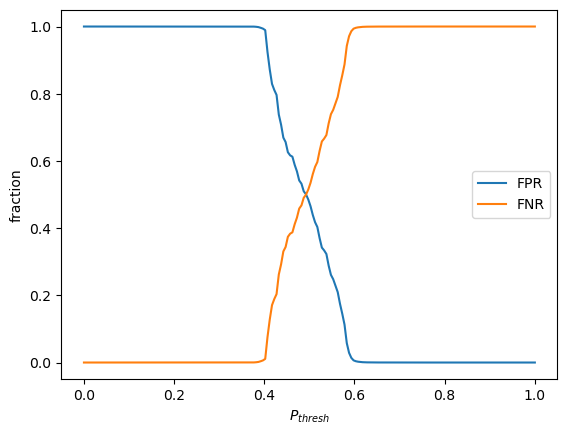

In [7]:
score_thresh = np.linspace(0, 1, 200)

tpr = [(prob_test_nu > score).sum() / len(prob_test_nu) for score in score_thresh]
fpr = [(prob_test_nubar > score).sum() / len(prob_test_nubar) for score in score_thresh]
tnr = [(prob_test_nu < score).sum() / len(prob_test_nu) for score in score_thresh]
fnr = [(prob_test_nubar < score).sum() / len(prob_test_nubar) for score in score_thresh]

plt.plot(score_thresh, tnr, label="TNR")
plt.plot(score_thresh, tpr, label="TPR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

plt.plot(score_thresh, fpr, label="FPR")
plt.plot(score_thresh, fnr, label="FNR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

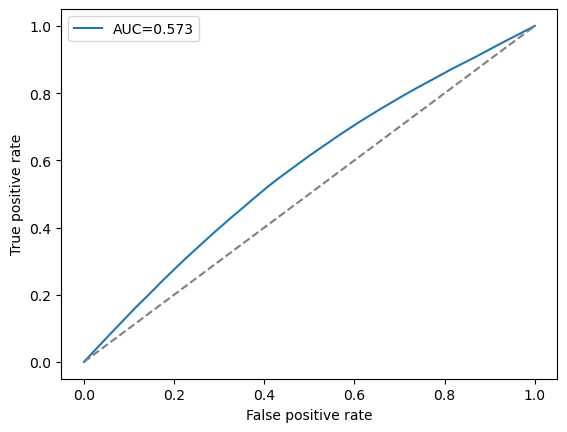

In [8]:
from scipy.integrate import trapezoid

auc = trapezoid(x=fpr[::-1], y=tpr[::-1])

# ROC
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

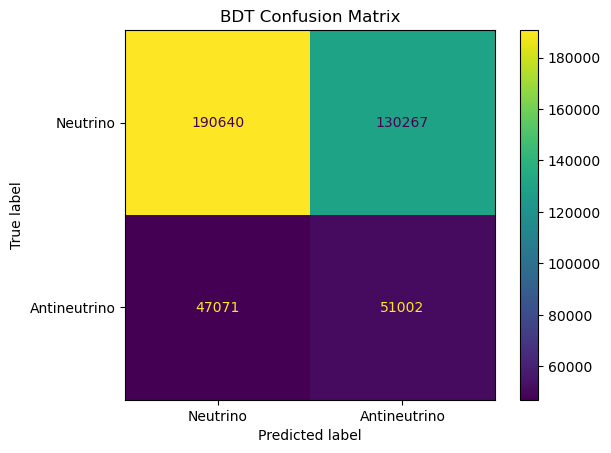

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Neutrino", "Antineutrino"])
disp.plot()
plt.title("BDT Confusion Matrix")
plt.show()

In [10]:
from sklearn.inspection import permutation_importance

r = permutation_importance(clf, X_data.to_pandas(), y_data, random_state=0)
for name, val in sorted(zip(X_data.columns, r["importances_mean"]), key=lambda x: x[1]):
    print(name, val)

Enu_mu_had -0.0029608864878153617
Enu_mu_range -0.002297846492397926
Enu_e_had -0.0007697278564511523
inelasticity -0.0005410769149069239
n_reco_pfps -0.0003038336624069382
single_hits_energy -0.00016575999885437565
n_reco_tracks -0.00010072097842557248
n_reco_muons_pions -4.3677580691703356e-05
n_primary_electrons -3.5204607388084066e-05
reco_ok 0.0
n_true_nu 0.0
n_primary_pions 7.518272086270983e-06
n_primary_pi0s 9.905025129497425e-06
n_reco_showers 1.4797868868177133e-05
n_primary_muons 2.6254283475823927e-05
n_primary_photons 2.8879711823392994e-05
n_primary_showers 3.0192425997199733e-05
n_primary_tracks 3.3772555562094905e-05
n_primary_daughters 7.136391599342762e-05
n_reco_protons 7.446669494968195e-05
n_primary_protons 0.00010835858816393706
direc_reco 0.0004626720774357773
Enu_e_calo 0.0007093430044566417
recoE 0.04481677791919285
